In [1]:
# ============================================================
# PRJN26-250 | Data-Driven Risk Profiling for Supply Chain
# Cell 1: Import LibrariesS
# ============================================================import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

All libraries loaded!
Pandas: 3.0.2
NumPy: 2.4.4


In [2]:
# ============================================================
# Cell 2: Define Risk Factors, Weights & Supplier Data
# ============================================================

# Risk factors and their weights (must sum to 1.0)
weights = {
    'Vendor_Financial_Health':      0.15,
    'Third_Party_Access_Control':   0.15,
    'Incident_Response_Readiness':  0.10,
    'Vulnerability_Management':     0.15,
    'Delivery_SLA_Performance':     0.10,
    'Compliance_Certification':     0.10,
    'Network_Security_Posture':     0.15,
    'Data_Privacy_Compliance':      0.10,
}

print(f"Total weight: {sum(weights.values()):.2f}")

data = {
    'Supplier': [
        'AlphaCore Systems', 'BetaNet Solutions', 'CoreVault Inc',
        'DataShield Ltd',    'EdgeTech Global',
        'FlexData Corp',     'GridSecure Co',    'HorizonIT Ltd',
        'InfraGuard Inc',    'JetLink Systems',
        'KeyNet Solutions',  'LogiSafe Corp',    'MetroData Ltd',
        'NexusIT Group',     'OmniCloud Inc'
    ],
    'Tier': [
        'Tier 1','Tier 1','Tier 1','Tier 1','Tier 1',
        'Tier 2','Tier 2','Tier 2','Tier 2','Tier 2',
        'Tier 3','Tier 3','Tier 3','Tier 3','Tier 3'
    ],
    'Vendor_Financial_Health':      [8,4,7,3,6,7,5,8,4,6,5,7,3,6,4],
    'Third_Party_Access_Control':   [7,8,6,7,4,6,8,5,7,4,5,6,7,3,6],
    'Incident_Response_Readiness':  [6,3,9,4,7,8,3,7,5,6,4,5,6,4,7],
    'Vulnerability_Management':     [8,5,7,2,6,7,5,8,3,6,6,4,5,7,3],
    'Delivery_SLA_Performance':     [7,6,8,5,3,6,7,8,5,4,7,5,6,4,8],
    'Compliance_Certification':     [9,4,8,3,8,7,4,9,3,7,5,6,4,8,3],
    'Network_Security_Posture':     [7,6,8,4,5,8,6,7,5,6,4,7,5,6,4],
    'Data_Privacy_Compliance':      [8,3,9,4,7,6,5,8,4,5,6,4,7,3,6],
}

df = pd.DataFrame(data)
print(f"Suppliers: {len(df)}")
print(f"Factors: {len(weights)}")
print(df[['Supplier','Tier']].to_string(index=False))

Total weight: 1.00
Suppliers: 15
Factors: 8
         Supplier   Tier
AlphaCore Systems Tier 1
BetaNet Solutions Tier 1
    CoreVault Inc Tier 1
   DataShield Ltd Tier 1
  EdgeTech Global Tier 1
    FlexData Corp Tier 2
    GridSecure Co Tier 2
    HorizonIT Ltd Tier 2
   InfraGuard Inc Tier 2
  JetLink Systems Tier 2
 KeyNet Solutions Tier 3
    LogiSafe Corp Tier 3
    MetroData Ltd Tier 3
    NexusIT Group Tier 3
    OmniCloud Inc Tier 3


In [6]:
# ============================================================
# Cell 2: Define Risk Factors, Weights & Supplier Data
# ============================================================

# Risk factors and their weights (must sum to 1.0)
weights = {
    'Vendor_Financial_Health':      0.20,
    'Third_Party_Access_Control':   0.20,
    'Incident_Response_Readiness':  0.15,
    'Vulnerability_Management':     0.20,
    'Delivery_SLA_Performance':     0.15,
    'Compliance_Certification':     0.10
}

# Supplier data - scores out of 10
data = {
    'Supplier': ['Supplier A', 'Supplier B', 'Supplier C', 'Supplier D', 'Supplier E'],
    'Vendor_Financial_Health':      [7, 4, 8, 3, 6],
    'Third_Party_Access_Control':   [6, 8, 5, 7, 4],
    'Incident_Response_Readiness':  [5, 3, 9, 4, 7],
    'Vulnerability_Management':     [8, 5, 7, 2, 6],
    'Delivery_SLA_Performance':     [6, 7, 8, 5, 3],
    'Compliance_Certification':     [9, 4, 7, 3, 8]
}

df = pd.DataFrame(data)
print("✅ Supplier Data Loaded!")
print(df)


✅ Supplier Data Loaded!
     Supplier  Vendor_Financial_Health  Third_Party_Access_Control  \
0  Supplier A                        7                           6   
1  Supplier B                        4                           8   
2  Supplier C                        8                           5   
3  Supplier D                        3                           7   
4  Supplier E                        6                           4   

   Incident_Response_Readiness  Vulnerability_Management  \
0                            5                         8   
1                            3                         5   
2                            9                         7   
3                            4                         2   
4                            7                         6   

   Delivery_SLA_Performance  Compliance_Certification  
0                         6                         9  
1                         7                         4  
2                         

In [10]:
# ============================================================
# Cell 3: Calculate Weighted Risk Scores
# ============================================================

# List of factor columns
factors = list(weights.keys())

df['Risk_Score'] = sum(df[factor] * weights[factor] for factor in factors)

def classify_risk(score):
    if score <= 3.0:   return 'Low'
    elif score <= 5.5: return 'Medium'
    elif score <= 7.5: return 'High'
    else:              return 'Critical'

df['Risk_Level'] = df['Risk_Score'].apply(classify_risk)

result = df[['Supplier','Tier','Risk_Score','Risk_Level']].sort_values(
    'Risk_Score', ascending=False).reset_index(drop=True)

print("Risk Scores Calculated!")
print("=" * 60)
print(result.to_string(index=False))
print("=" * 60)
print(f"\nHighest Risk : {result.iloc[0]['Supplier']}  ({result.iloc[0]['Risk_Score']:.2f})")
print(f"Lowest Risk  : {result.iloc[-1]['Supplier']}  ({result.iloc[-1]['Risk_Score']:.2f})")
print(f"Average Score: {df['Risk_Score'].mean():.2f}")

Risk Scores Calculated!
         Supplier   Tier  Risk_Score Risk_Level
    CoreVault Inc Tier 1        7.60   Critical
AlphaCore Systems Tier 1        7.50       High
    HorizonIT Ltd Tier 2        7.40       High
    FlexData Corp Tier 2        6.90       High
  EdgeTech Global Tier 1        5.65       High
    LogiSafe Corp Tier 3        5.60       High
    GridSecure Co Tier 2        5.50     Medium
  JetLink Systems Tier 2        5.50     Medium
    MetroData Ltd Tier 3        5.30     Medium
    NexusIT Group Tier 3        5.20     Medium
 KeyNet Solutions Tier 3        5.20     Medium
BetaNet Solutions Tier 1        5.05     Medium
    OmniCloud Inc Tier 3        4.95     Medium
   InfraGuard Inc Tier 2        4.55     Medium
   DataShield Ltd Tier 1        4.00     Medium

Highest Risk : CoreVault Inc  (7.60)
Lowest Risk  : DataShield Ltd  (4.00)
Average Score: 5.73


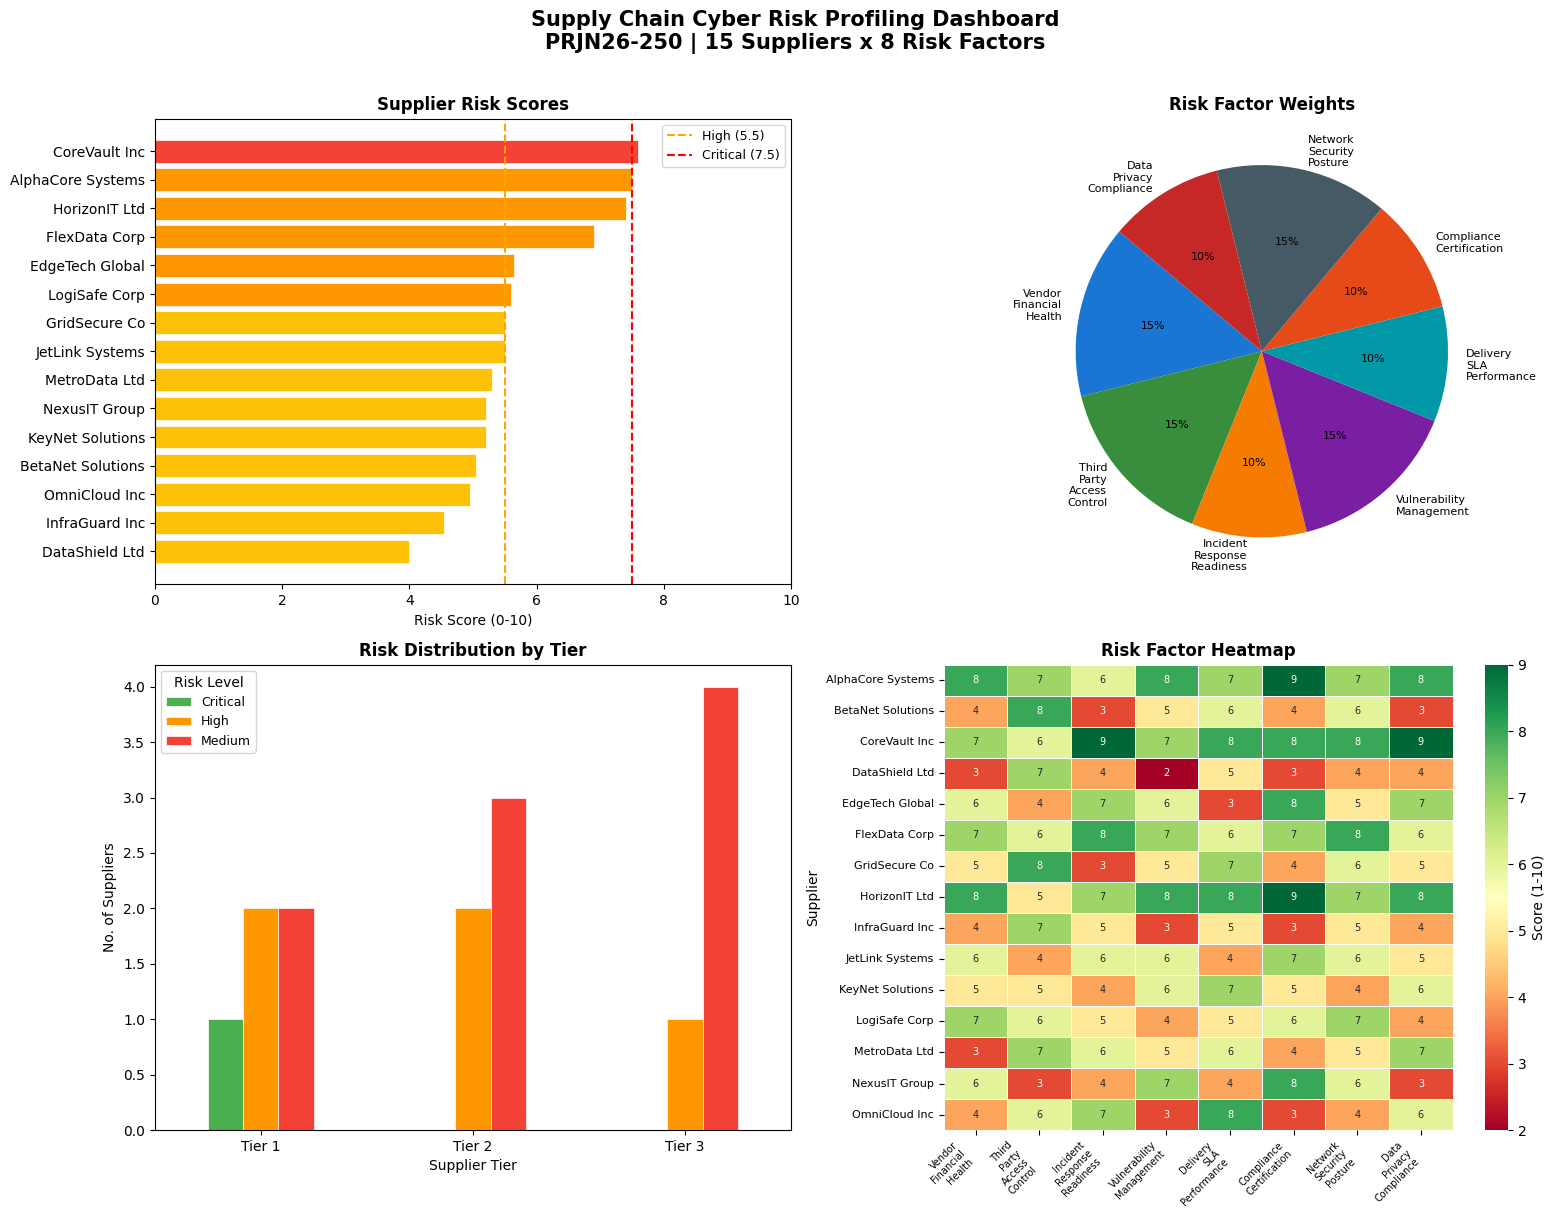

Dashboard saved!


In [11]:
# ============================================================
# Cell 4: Visualize Risk Scores
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Supply Chain Cyber Risk Profiling Dashboard\nPRJN26-250 | 15 Suppliers x 8 Risk Factors',
             fontsize=15, fontweight='bold', y=1.01)

color_map = {'Low':'#4CAF50','Medium':'#FFC107','High':'#FF9800','Critical':'#F44336'}
bar_colors = [color_map[lvl] for lvl in result['Risk_Level']]

# Chart 1: Risk Score Bar Chart
axes[0,0].barh(result['Supplier'], result['Risk_Score'],
               color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0,0].axvline(x=5.5, color='orange', linestyle='--', linewidth=1.5, label='High (5.5)')
axes[0,0].axvline(x=7.5, color='red',    linestyle='--', linewidth=1.5, label='Critical (7.5)')
axes[0,0].set_xlabel('Risk Score (0-10)')
axes[0,0].set_title('Supplier Risk Scores', fontweight='bold')
axes[0,0].set_xlim(0, 10)
axes[0,0].legend(fontsize=9)
axes[0,0].invert_yaxis()

# Chart 2: Weights Pie Chart
wedge_colors = ['#1976D2','#388E3C','#F57C00','#7B1FA2',
                '#0097A7','#E64A19','#455A64','#C62828']
axes[0,1].pie(weights.values(),
              labels=[k.replace('_','\n') for k in weights.keys()],
              autopct='%1.0f%%', startangle=140,
              colors=wedge_colors, textprops={'fontsize':8})
axes[0,1].set_title('Risk Factor Weights', fontweight='bold')

# Chart 3: Tier Distribution
tier_risk = df.groupby(['Tier','Risk_Level']).size().unstack(fill_value=0)
tier_risk.plot(kind='bar', ax=axes[1,0],
               color=['#4CAF50','#FF9800','#F44336','#FFC107'],
               edgecolor='white', linewidth=0.5)
axes[1,0].set_title('Risk Distribution by Tier', fontweight='bold')
axes[1,0].set_xlabel('Supplier Tier')
axes[1,0].set_ylabel('No. of Suppliers')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(title='Risk Level', fontsize=9)

# Chart 4: Heatmap
heat_data = df.set_index('Supplier')[factors]
sns.heatmap(heat_data, ax=axes[1,1], cmap='RdYlGn',
            annot=True, fmt='d', linewidths=0.4,
            cbar_kws={'label':'Score (1-10)'},
            annot_kws={'size':7})
axes[1,1].set_title('Risk Factor Heatmap', fontweight='bold')
axes[1,1].set_xticklabels([f.replace('_','\n') for f in factors],
                           fontsize=7, rotation=45, ha='right')
axes[1,1].set_yticklabels(axes[1,1].get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig('risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

In [12]:
# ============================================================
# Cell 5: Export Results & Final Summary
# ============================================================

# Add individual weighted scores for each factor
for factor in factors:
    df[f'Weighted_{factor}'] = (df[factor] * weights[factor]).round(3)

df.to_csv('risk_profiling_results.csv', index=False)

critical = len(df[df['Risk_Score'] > 7.5])
high     = len(df[(df['Risk_Score'] > 5.5) & (df['Risk_Score'] <= 7.5)])
medium   = len(df[(df['Risk_Score'] > 3.0) & (df['Risk_Score'] <= 5.5)])
low      = len(df[df['Risk_Score'] <= 3.0])

print("=" * 60)
print("   SUPPLY CHAIN CYBER RISK PROFILING - FINAL REPORT")
print("         PRJN26-250 | Yenepoya Institute")
print("=" * 60)
print(f"\nTotal Suppliers Assessed  : {len(df)}")
print(f"Risk Factors Evaluated    : {len(factors)}")
print(f"Supplier Tiers            : Tier 1 / Tier 2 / Tier 3")
print(f"\nCritical Risk Suppliers   : {critical}")
print(f"High Risk Suppliers       : {high}")
print(f"Medium Risk Suppliers     : {medium}")
print(f"Low Risk Suppliers        : {low}")
print(f"\nAverage Risk Score        : {df['Risk_Score'].mean():.2f}")
print(f"Minimum Risk Score        : {df['Risk_Score'].min():.2f}")
print(f"Maximum Risk Score        : {df['Risk_Score'].max():.2f}")
print(f"\nHighest Risk Supplier     : {df.loc[df['Risk_Score'].idxmax(), 'Supplier']}")
print(f"Lowest Risk Supplier      : {df.loc[df['Risk_Score'].idxmin(), 'Supplier']}")
print(f"\nResults exported to       : risk_profiling_results.csv")
print(f"Dashboard saved to        : risk_dashboard.png")
print(f"\nProject PRJN26-250 Complete!")
print("=" * 60)

   SUPPLY CHAIN CYBER RISK PROFILING - FINAL REPORT
         PRJN26-250 | Yenepoya Institute

Total Suppliers Assessed  : 15
Risk Factors Evaluated    : 8
Supplier Tiers            : Tier 1 / Tier 2 / Tier 3

Critical Risk Suppliers   : 1
High Risk Suppliers       : 5
Medium Risk Suppliers     : 9
Low Risk Suppliers        : 0

Average Risk Score        : 5.73
Minimum Risk Score        : 4.00
Maximum Risk Score        : 7.60

Highest Risk Supplier     : CoreVault Inc
Lowest Risk Supplier      : DataShield Ltd

Results exported to       : risk_profiling_results.csv
Dashboard saved to        : risk_dashboard.png

Project PRJN26-250 Complete!


In [13]:
# ============================================================
# Cell 5: Export Results & Final Summary
# ============================================================

# Add individual weighted scores for each factor
for factor in factors:
    df[f'Weighted_{factor}'] = (df[factor] * weights[factor]).round(3)

df.to_csv('risk_profiling_results.csv', index=False)

critical = len(df[df['Risk_Score'] > 7.5])
high     = len(df[(df['Risk_Score'] > 5.5) & (df['Risk_Score'] <= 7.5)])
medium   = len(df[(df['Risk_Score'] > 3.0) & (df['Risk_Score'] <= 5.5)])
low      = len(df[df['Risk_Score'] <= 3.0])

print("=" * 60)
print("   SUPPLY CHAIN CYBER RISK PROFILING - FINAL REPORT")
print("         PRJN26-250 | Yenepoya Institute")
print("=" * 60)
print(f"\nTotal Suppliers Assessed  : {len(df)}")
print(f"Risk Factors Evaluated    : {len(factors)}")
print(f"Supplier Tiers            : Tier 1 / Tier 2 / Tier 3")
print(f"\nCritical Risk Suppliers   : {critical}")
print(f"High Risk Suppliers       : {high}")
print(f"Medium Risk Suppliers     : {medium}")
print(f"Low Risk Suppliers        : {low}")
print(f"\nAverage Risk Score        : {df['Risk_Score'].mean():.2f}")
print(f"Minimum Risk Score        : {df['Risk_Score'].min():.2f}")
print(f"Maximum Risk Score        : {df['Risk_Score'].max():.2f}")
print(f"\nHighest Risk Supplier     : {df.loc[df['Risk_Score'].idxmax(), 'Supplier']}")
print(f"Lowest Risk Supplier      : {df.loc[df['Risk_Score'].idxmin(), 'Supplier']}")
print(f"\nResults exported to       : risk_profiling_results.csv")
print(f"Dashboard saved to        : risk_dashboard.png")
print(f"\nProject PRJN26-250 Complete!")
print("=" * 60)

   SUPPLY CHAIN CYBER RISK PROFILING - FINAL REPORT
         PRJN26-250 | Yenepoya Institute

Total Suppliers Assessed  : 15
Risk Factors Evaluated    : 8
Supplier Tiers            : Tier 1 / Tier 2 / Tier 3

Critical Risk Suppliers   : 1
High Risk Suppliers       : 5
Medium Risk Suppliers     : 9
Low Risk Suppliers        : 0

Average Risk Score        : 5.73
Minimum Risk Score        : 4.00
Maximum Risk Score        : 7.60

Highest Risk Supplier     : CoreVault Inc
Lowest Risk Supplier      : DataShield Ltd

Results exported to       : risk_profiling_results.csv
Dashboard saved to        : risk_dashboard.png

Project PRJN26-250 Complete!
